In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()

# Put into DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target  # target in $100,000s

print(f"Dataset shape: {df.shape}")
print(f"\nFeature names:\n{housing.feature_names}")
print("\nFirst 5 rows:")
print(df.head())

print("\nBasic statistics:")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

Correlation with target (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


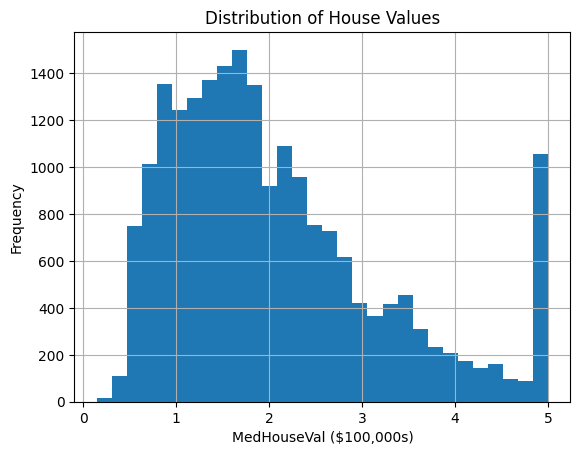

In [2]:
# Correlation matrix
corr_matrix = df.corr()

print("Correlation with target (MedHouseVal):")
print(corr_matrix["MedHouseVal"].sort_values(ascending=False))

# Plot histogram of target
plt.figure()
df["MedHouseVal"].hist(bins=30)
plt.xlabel("MedHouseVal ($100,000s)")
plt.ylabel("Frequency")
plt.title("Distribution of House Values")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train/Test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData standardized successfully.")

Train shape: (16512, 8)
Test shape: (4128, 8)

Data standardized successfully.


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
lin_reg = LinearRegression()

# Train model
lin_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = lin_reg.predict(X_test_scaled)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("MSE:", round(mse, 4))
print("R2 Score:", round(r2, 4))

Linear Regression Results:
MSE: 0.5559
R2 Score: 0.5758


In [5]:
from sklearn.linear_model import Ridge

# Create Ridge model
ridge = Ridge(alpha=1.0)

# Train
ridge.fit(X_train_scaled, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results:")
print("MSE:", round(mse_ridge, 4))
print("R2 Score:", round(r2_ridge, 4))

Ridge Regression Results:
MSE: 0.5559
R2 Score: 0.5758


In [6]:
from sklearn.linear_model import Lasso

# Create Lasso model
lasso = Lasso(alpha=0.01)

# Train
lasso.fit(X_train_scaled, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluate
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results:")
print("MSE:", round(mse_lasso, 4))
print("R2 Score:", round(r2_lasso, 4))

Lasso Regression Results:
MSE: 0.5483
R2 Score: 0.5816


In [7]:
print("=== Model Comparison ===")
print(f"Linear Regression  -> R2: {round(r2,4)} | MSE: {round(mse,4)}")
print(f"Ridge Regression   -> R2: {round(r2_ridge,4)} | MSE: {round(mse_ridge,4)}")
print(f"Lasso Regression   -> R2: {round(r2_lasso,4)} | MSE: {round(mse_lasso,4)}")

=== Model Comparison ===
Linear Regression  -> R2: 0.5758 | MSE: 0.5559
Ridge Regression   -> R2: 0.5758 | MSE: 0.5559
Lasso Regression   -> R2: 0.5816 | MSE: 0.5483


Conclusion

In this lab, we applied three linear regression variants: Linear Regression, Ridge, and Lasso on the California Housing dataset.

The results showed that Linear Regression and Ridge produced almost identical performance, with an R² score of approximately 0.576. This indicates that regularization with Ridge (alpha = 1.0) did not significantly impact performance.

However, Lasso Regression achieved the best performance with an R² score of approximately 0.582 and the lowest MSE. This suggests that Lasso’s L1 regularization helped improve generalization by slightly reducing overfitting and potentially shrinking less important features.

Overall, Lasso performed best for this dataset, while Ridge behaved similarly to standard Linear Regression.